# Tasks i-vi

## Setup

**Load packages**


In [1]:
import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import comb

**Load data**

In [2]:
#load data
Code_folder= Path.cwd().parent
data = pd.read_csv(Code_folder / "Data" / "aapl_28apr.csv", header=2)
#rename columns and to date time format
data.columns=["Date", "Price level"]
data["Date"]= pd.to_datetime(data["Date"])
data.set_index("Date", inplace=True)
print(data)

            Price level
Date                   
2020-01-02    72.400513
2020-01-03    71.696640
2020-01-06    72.267944
2020-01-07    71.928055
2020-01-08    73.085136
...                 ...
2026-04-22   273.170013
2026-04-23   273.429993
2026-04-24   271.059998
2026-04-27   267.609985
2026-04-28   270.709991

[1588 rows x 1 columns]


**Define and derive variables and model parameters**

In [3]:
#define S_0 as the observation from 28.04.2026
S_0=data["Price level"].iloc[-1]
#make a log return column
data["Log return"]= np.log(data["Price level"] /data["Price level"].shift(1))
#use historical daily returns up to 27.04 2026 for volatility
returns_for_volatility=data.loc[: "2026-04-27", "Log return"].dropna()
#daily  volatility as standard deviation
sigma_daily=returns_for_volatility.std()
#annualize volatility
sigma = sigma_daily*np.sqrt(250)
print("annualized volatility equals", sigma)

#given model parameters
T= 0.5 #this means 6 months
n= 25
r= 0.01       
#time step
delta_t= T/n
#up and down factors
u= np.exp(sigma* np.sqrt(delta_t))
d=np.exp(-sigma*np.sqrt(delta_t))
#real probability, as specified in the exercise
p=0.5
#risk neutral probability


annualized volatility equals 0.3131007174283117


## Task i: Build binomial tree


Build a binomial tree, first building the binomial tree using the method described in https://www.kaggle.com/code/ahmetgokkaya/pricing-derivatives-with-binomial-tree-model/notebook.

In [4]:
def binomial_tree(S_0, u, d, n):
    #initialize n+1 x n+1 matrix with entry [j, t] holding price at time t with
    #j down-moves (-> t-j up-moves)
    stock_tree=np.zeros((n+1, n+1))
    #set value of t=0 into matrix
    stock_tree[0, 0]= S_0
    #fill in the binomial tree like formula
    for i in range(1, n+1):
        for j in range(i+1):
            stock_tree[j, i]=S_0*u**(i-j)*d**j
   
    return stock_tree  


In [5]:
stock_tree = binomial_tree(S_0, u, d, n)

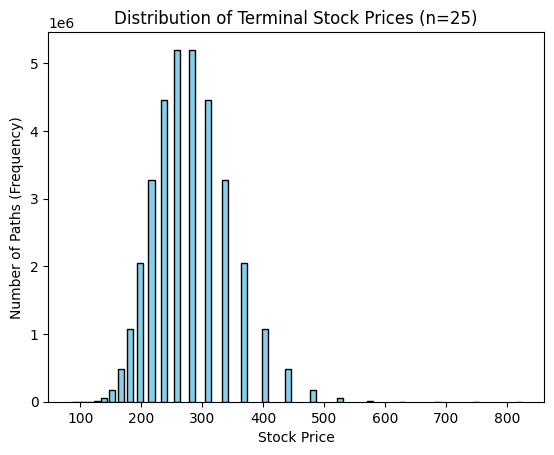

In [6]:
# Calculate number of paths to each terminal node j at time n
paths = [comb(n, j) for j in range(n + 1)]
terminal_prices = stock_tree[:, n]

plt.bar(terminal_prices, paths, width=10, color='skyblue', edgecolor='black')
plt.title(f"Distribution of Terminal Stock Prices (n={n})")
plt.xlabel("Stock Price")
plt.ylabel("Number of Paths (Frequency)")
plt.show()

## Task ii: Calculate the arithmetic average stock price

**Function to capture sum (=path dependent)**:
Need to capture the fact that although at maturity time $T$ some $S_j$ will have the same payoff, they have gone through a different path and therefore have a different sum. We follow for this the idea of an augmented state space of Hull, J. and White, A. (1993). Efficient procedures for valuing European and American path-dependent options. Journal of Derivatives, 1(1), 21–31. but instead of interpolation we'll store every reachable sum using a dictionary. This will ease later computations.

We count (in the dictionary) how many paths lead to the same arithmetic average at the same terminal stock node because in binomial trees same average may be reached by more than one path. For option pricing later, this matters because the option value depends on the probability-weighted payoff.

We round entries to 10 decimals to avoid artificial duplicate states caused by tiny floating-point errors.

In [7]:
def Sum(S_0, u, d, n):
    #get matrix of the binomial tree prices
    stock_tree=binomial_tree(S_0, u, d, n)
    #initialize tree of dictionaries to capture the sum
    tree_dics=[[{} for k in range(t+1)] for t in range(n+1)]
    #for t=0 we already know the initial price which is also the sum at t=0
    tree_dics[0][0]= {round(S_0, 10): 1}
    #build sum dictionaries
    for t in range(n):
        for k in range(t+1):
            for total_sum, count in tree_dics[t][k].items():
                #up move-> get to node (k, t+1)
                S_up=stock_tree[k, t+1]
                #add S_up to the sum
                new_sum_up=round(total_sum + S_up, 10)
                tree_dics[t+1][k][new_sum_up]=tree_dics[t+1][k].get(new_sum_up, 0)+count
                
                #down move-> get to node (k+1, t+1)
                S_down=stock_tree[k+1, t+1]
                new_sum_down=round(total_sum + S_down, 10)
                tree_dics[t+1][k+1][new_sum_down]=tree_dics[t+1][k+1].get(new_sum_down, 0)+count

    return tree_dics

**Get the arithmetic mean**

In [8]:
def arithmetic_mean(S_0, u, d, n):
    #get dic of sum
    tree_dics= Sum(S_0, u, d, n)
    #initialize dictionary for the arithmetic average for each terminal node
    mean_dics= [{} for node in range(n+1)]
    #loop through nodes and get for all sum entries the arithmetic average
    for k in range(n+1):
        for total_sum, count in tree_dics[n][k].items():
            #arithmetic average
            avg=round(total_sum/(n+1), 10)
            mean_dics[k][avg]=mean_dics[k].get(avg, 0)+count
    
    return mean_dics

In [9]:
#print result all upmoves
print(arithmetic_mean(S_0, u, d, n)[0])

{np.float64(497.2449734841): 1}


In [10]:
tree_dics= Sum(S_0, u, d, n)
mean_dics= arithmetic_mean(S_0, u, d, n)

## Task iii: floating-strike Asian call option

In [11]:
def Asian_call(S_0, u, d, n):
    #get stock price matrix and sum dictionaries
    stock_tree= binomial_tree(S_0, u, d, n)
    tree_dics= Sum(S_0, u, d, n)    
    #initialize dictionary to store payoffs at each terminal node 
    payoff_dics=[{} for node in range(n+1)]    
    #go through all terminal nodes and calculate the payoff of call option
    for k in range(n+1):
        S_n=stock_tree[k, n]
        for total_sum, count in tree_dics[n][k].items():
            #round cumulative sum again to avoid artificial duplicate states caused by floating-point errors
            total_sum=round(total_sum, 10)
            #arithmetic average
            avg=round(total_sum/(n+1), 10)
            #floating-strike Asian call payoff
            payoff=max(S_n-avg, 0)
            #use total_sum as key because later tasks need the cumulative sum state
            payoff_dics[k][total_sum]={"S_n": S_n, "avg": avg, "payoff": payoff, "count": count}    
    return payoff_dics

In [12]:
#print call payoff from all up movement
asian_call=Asian_call(S_0, u, d, n)
print(asian_call[0])

{np.float64(12928.3693105873): {'S_n': np.float64(818.9526830055984), 'avg': np.float64(497.2449734841), 'payoff': np.float64(321.7077095214984), 'count': 1}}


In [13]:
payoff_dics = Asian_call(S_0, u, d, n)

## Plotting for Tasks i-iii

In [ ]:
#get data
payoff_data= Asian_call(S_0, u, d, n)
stock_tree= binomial_tree(S_0, u, d, n)
#extract data for plotting
terminal_prices=[]
all_averages=[]
all_payoffs= []
differences= []

for k in range(n + 1):
    for total_sum, data in payoff_data[k].items():
        #replicate values by 'count' to represent the full distribution of paths
        count=data['count']
        terminal_prices.extend([data['S_n']]*count)
        all_averages.extend([data['avg']] *count)
        all_payoffs.extend([data['payoff']]* count)
        differences.extend([data['S_n'] -data['avg']]* count)

#Plot 1: Terminal Stock Price vs. Arithmetic Average 
plt.figure(figsize=(10, 6))
plt.scatter(terminal_prices, all_averages, alpha=0.1, color='blue', s=1)
plt.title(fr'Path Dependency: Terminal Price $S_n$ vs. Arithmetic Average $\overline{{S}}_n$ (n={n})')
plt.xlabel(r'Terminal Stock Price $S_n$')
plt.ylabel(r'Arithmetic Average $\overline{{S}}_n$')

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#Plot 2: Distribution of Floating-Strike Asian Call Payoffs
plt.figure(figsize=(10, 6))
plt.hist(all_payoffs, bins=50, color='seagreen', edgecolor='black', alpha=0.7)
plt.title('Distribution of Option Payoffs at Maturity $T$')
plt.xlabel(fr'Payoff $A_T = \max(S_n - \overline{{S}}_n, 0)$')
plt.ylabel('Frequency (Number of Paths)')
plt.yscale('log') 
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#Plot 3: Payoff Diagram
plt.figure(figsize=(10, 6))
plt.scatter(differences, all_payoffs, color='darkorange', s=5, alpha=0.5)
plt.title('Asian Call Payoff vs. Price-Average Difference')
plt.xlabel('Difference ($D_n = S_n - \\overline{{S}}_n$)')
plt.ylabel('Option Payoff $A_T$')
plt.axvline(0, color='black', linewidth=1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Task iv: compute the risk neutral probabilities
Using the previously calculated variables:
  $$q = \frac{e^{r \Delta t} - d}{u - d}$$

In [ ]:
# Calculate risk neutral probability q
q = (np.exp(r * delta_t) - d) / (u - d)
q_down = 1 - q
print(f"Risk-neutral probability of up move (q): {q}")
print(f"Risk-neutral probability of down move (1-q): {q_down}")

Risk-neutral probability of up move (q): 0.4911899146278396
Risk-neutral probability of down move (1-q): 0.5088100853721604


## Task v: backward induction

  $$V_t = e^{-r \Delta t} \left[ q \cdot V_{t+\Delta t}^u + (1-q) \cdot V_{t+\Delta t}^d \right]$$

  $$V(t, \text{Sum}) = e^{-r \Delta t} \left[ q \cdot V(t+\Delta t, \text{Sum} + S_{up}) + (1-q) \cdot V(t+\Delta t, \text{Sum} + S_{down}) \right]$$

In [ ]:


def neut_val(payoff_up, payoff_down):
    return np.exp(-r * delta_t) * (q * payoff_up + q_down * payoff_down)

def step_back(Sum, future_value_tree, k, t):
    # Calculate the exact sums expected in the future nodes
    value_up = round(Sum + stock_tree[k, t+1], 10)   
    value_down = round(Sum + stock_tree[k+1, t+1], 10)
    
    # Retrieve the float option values from the t+1 dictionary
    # If the key isn't found, default to 0.0 (though it should always be found)
    payoff_up = future_value_tree[k].get(value_up, 0.0)
    payoff_down = future_value_tree[k+1].get(value_down, 0.0)

    # Calculate discounted expectation
    return neut_val(payoff_up, payoff_down)


In [ ]:
def expected_value(S_0, u, d, n, r):
    # Initialize value tree going backwards
    value_tree = [[{} for k in range(t+1)] for t in range(n+1)]
    
    # 1. Fill the terminal nodes (T=n) using the previously calculated payoff_dics
    for k in range(n + 1):
        for total_sum, data in payoff_dics[k].items():
            value_tree[n][k][total_sum] = data['payoff']
            
    # 2. Go backwards from T=n-1 to T=0
    for t in range(n - 1, -1, -1):
        for k in range(t + 1):
            for total_sum in tree_dics[t][k].keys():
                # We pass value_tree[t+1] which contains the float values
                value_tree[t][k][total_sum] = step_back(total_sum, value_tree[t+1], k, t)

    # Return the fair price of the option at node [0,0]
    fair_price = value_tree[0][0][round(S_0, 10)]
    print(f"The fair price of the floating-strike Asian call option is: {fair_price}")
    
    return value_tree

val_tree = expected_value(S_0, u, d, n, r)


The fair price of the floating-strike Asian call option is: 14.054203819677118


## Task vi: Robustness

Define a model that calls the functions, of tasks i-iii with recomputed parameters depending on r/$\sigma$. And doing backward induction based on the new outputs.

In [ ]:
def run_model(S_0, sigma, r, T=0.5, n=25):
    #calculate the length of each time step
    delta_t=T/n    
    #recompute up/down factors based on volatility and time step
    u=np.exp(sigma* np.sqrt(delta_t))
    d= np.exp(-sigma*np.sqrt(delta_t))    
    #recompute risk-neutral probability for up and down moves
    q= (np.exp(r *delta_t)-d)/(u-d)
    q_down =1-q    
    #get the stock price tree, possible sums, and terminal payoffs
    stock_tree = binomial_tree(S_0, u, d, n)
    tree_dics = Sum(S_0, u, d, n)
    payoff_dics = Asian_call(S_0, u, d, n)    
    #initialize a tree of dictionaries to store option values at each node/sum
    value_tree = [[{} for k in range(t + 1)] for t in range(n + 1)]    
    #populate the terminal values (at time T) from the payoff dictionaries
    for k in range(n + 1):
        for total_sum, data in payoff_dics[k].items():
            value_tree[n][k][total_sum] = data["payoff"]    
    #perform backward induction to find the option value at earlier time steps
    for t in range(n - 1, -1, -1):
        for k in range(t + 1):
            for total_sum in tree_dics[t][k].keys():                
                #calculate the potential sums for the next time step (up and down)
                value_up_sum = round(total_sum + stock_tree[k, t + 1], 10)
                value_down_sum = round(total_sum + stock_tree[k + 1, t + 1], 10)                
                #retrieve the continuation values from the subsequent nodes
                value_up = value_tree[t + 1][k][value_up_sum]
                value_down = value_tree[t + 1][k + 1][value_down_sum]                
                #discount the expected value back one time step
                value_tree[t][k][total_sum]=np.exp(-r * delta_t)*(q * value_up + q_down * value_down)
    
    #the option price is the value at t=0 for the initial stock price sum
    option_price = value_tree[0][0][round(S_0, 10)]
    
    return option_price

quick test whether get same value

In [ ]:
print (run_model(S_0, sigma, 0.01))

14.054203819677118


Define baseline with previous parameters.

In [ ]:
# Baseline parameters
r_base = 0.01
sigma_base = sigma

# Baseline option price
base_price = run_model(S_0, sigma_base, r_base, T, n)

print("Baseline case:")
print(f"r = {r_base:.4f}")
print(f"sigma = {sigma_base:.4f}")
print(f"Baseline option price A_0 = {base_price:.4f}")
print()

Baseline case:
r = 0.0100
sigma = 0.3131
Baseline option price A_0 = 14.0542



**Sensitivity to r**

In [19]:
# Keep sigma fixed, vary r.

r_grid = np.array([0.0, 0.005, 0.01, 0.02, 0.03, 0.04, 0.05])

r_prices = np.array([
    run_model(S_0, sigma_base, r_test, T, n)
    for r_test in r_grid
])

r_table = pd.DataFrame({
    "r": r_grid,
    "sigma": sigma_base,
    "A_0": r_prices,
    "% change vs base": 100 * (r_prices - base_price) / base_price
})

print("Sensitivity to r, with sigma fixed at baseline:")
print(r_table.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print()


Sensitivity to r, with sigma fixed at baseline:
     r  sigma     A_0  % change vs base
0.0000 0.3131 13.7364           -2.2609
0.0050 0.3131 13.8948           -1.1341
0.0100 0.3131 14.0542            0.0000
0.0200 0.3131 14.3760            2.2898
0.0300 0.3131 14.7019            4.6083
0.0400 0.3131 15.0317            6.9552
0.0500 0.3131 15.3655            9.3305



**Sensitivity to sigma**

In [20]:
sigma_grid = np.array([0.20, 0.25, 0.30, sigma, 0.35, 0.40, 0.45])
sigma_grid = np.sort(np.unique(np.round(sigma_grid, 4)))

sigma_prices = np.array([
    run_model(S_0, sigma_test, r_base, T, n)
    for sigma_test in sigma_grid
])

sigma_table = pd.DataFrame({
    "sigma": sigma_grid,
    "r": r_base,
    "A_0": sigma_prices,
    "% change vs base": 100 * (sigma_prices - base_price) / base_price
})

print("Sensitivity to sigma, with r fixed at 1%:")
print(sigma_table.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print()

Sensitivity to sigma, with r fixed at 1%:
 sigma      r     A_0  % change vs base
0.2000 0.0100  9.1083          -35.1919
0.2500 0.0100 11.2959          -19.6259
0.3000 0.0100 13.4818           -4.0726
0.3131 0.0100 14.0542           -0.0002
0.3500 0.0100 15.6654           11.4644
0.4000 0.0100 17.8463           26.9817
0.4500 0.0100 20.0239           42.4762



**Joint robustness grid**

In [21]:
r_grid_2d = np.array([0.00, 0.01, 0.02, 0.03, 0.04, 0.05])
sigma_grid_2d = np.array([0.20, 0.25, 0.30, 0.35, 0.40, 0.45])

joint_prices = np.full((len(sigma_grid_2d), len(r_grid_2d)), np.nan)

for i, sigma_test in enumerate(sigma_grid_2d):
    for j, r_test in enumerate(r_grid_2d):
        try:
            joint_prices[i, j] = run_model(S_0, sigma_test, r_test, T, n)
        except Exception as e:
            print(f"Failed for sigma = {sigma_test:.4f}, r = {r_test:.4f}")
            print("Error:", e)

joint_table = pd.DataFrame(
    joint_prices,
    index=[f"{s:.0%}" for s in sigma_grid_2d],
    columns=[f"{r:.1%}" for r in r_grid_2d]
)

joint_table.index.name = "sigma \\ r"

print("Joint robustness grid: option price A_0")
print(joint_table.to_string(float_format=lambda x: f"{x:.4f}"))
print()

Joint robustness grid: option price A_0
             0.0%    1.0%    2.0%    3.0%    4.0%    5.0%
sigma \ r                                                
20%        8.7809  9.1083  9.4426  9.7838 10.1318 10.4866
25%       10.9730 11.2959 11.6242 11.9578 12.2967 12.6408
30%       13.1630 13.4818 13.8049 14.1323 14.4638 14.7996
35%       15.3506 15.6654 15.9838 16.3056 16.6310 16.9597
40%       17.5353 17.8463 18.1602 18.4770 18.7968 19.1194
45%       19.7168 20.0239 20.3335 20.6457 20.9603 21.2775



Saved figure -> robustness_plots.png


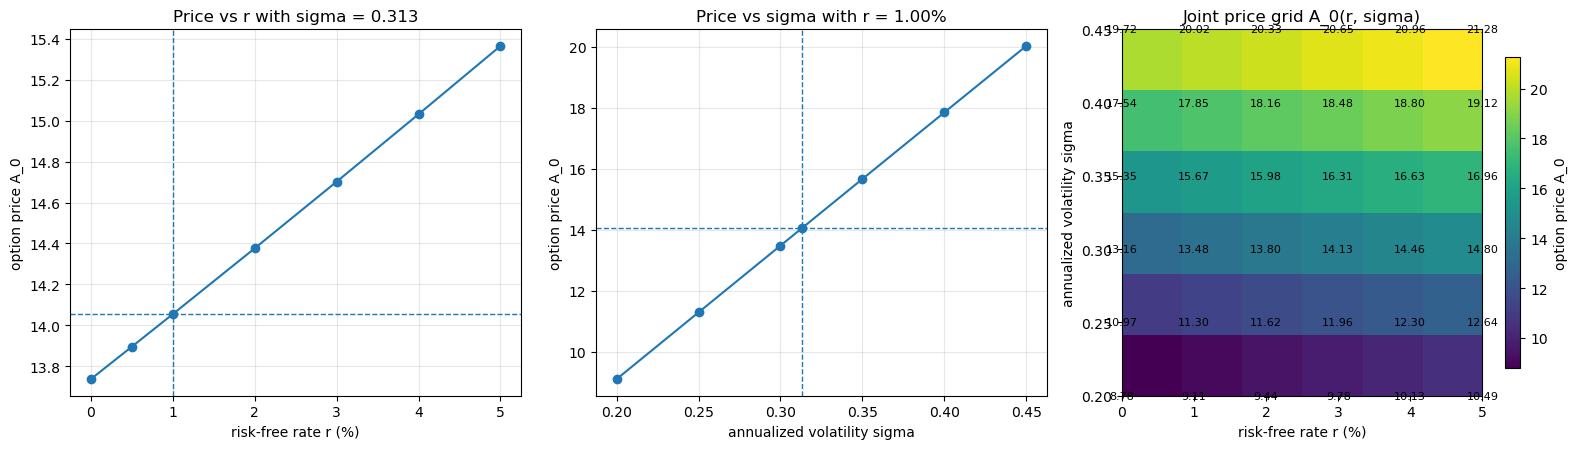

In [22]:
# --- 4) plots ---------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

# (a) price vs r
axes[0].plot(r_grid * 100, r_prices, "o-")
axes[0].axvline(r_base * 100, ls="--", lw=1)
axes[0].axhline(base_price, ls="--", lw=1)
axes[0].set_xlabel("risk-free rate r (%)")
axes[0].set_ylabel("option price A_0")
axes[0].set_title(f"Price vs r with sigma = {sigma_base:.3f}")
axes[0].grid(alpha=0.3)

# (b) price vs sigma
axes[1].plot(sigma_grid, sigma_prices, "o-")
axes[1].axvline(sigma_base, ls="--", lw=1)
axes[1].axhline(base_price, ls="--", lw=1)
axes[1].set_xlabel("annualized volatility sigma")
axes[1].set_ylabel("option price A_0")
axes[1].set_title(f"Price vs sigma with r = {100 * r_base:.2f}%")
axes[1].grid(alpha=0.3)

# (c) joint heatmap
im = axes[2].imshow(
    joint_prices,
    origin="lower",
    aspect="auto",
    extent=[
        r_grid_2d[0] * 100,
        r_grid_2d[-1] * 100,
        sigma_grid_2d[0],
        sigma_grid_2d[-1]
    ]
)

for i, sigma_test in enumerate(sigma_grid_2d):
    for j, r_test in enumerate(r_grid_2d):
        axes[2].text(
            r_test * 100,
            sigma_test,
            f"{joint_prices[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

axes[2].set_xlabel("risk-free rate r (%)")
axes[2].set_ylabel("annualized volatility sigma")
axes[2].set_title("Joint price grid A_0(r, sigma)")

plt.colorbar(im, ax=axes[2], shrink=0.85, label="option price A_0")

plt.tight_layout()
plt.savefig("robustness_plots.png", dpi=130, bbox_inches="tight")
print("Saved figure -> robustness_plots.png")